In [5]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

/tmp/ipykernel_42658/3443658841.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_centroid = selected_grid.geometry.centroid.iloc[0]
/tmp/ipykernel_42658/3443658841.py:61: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


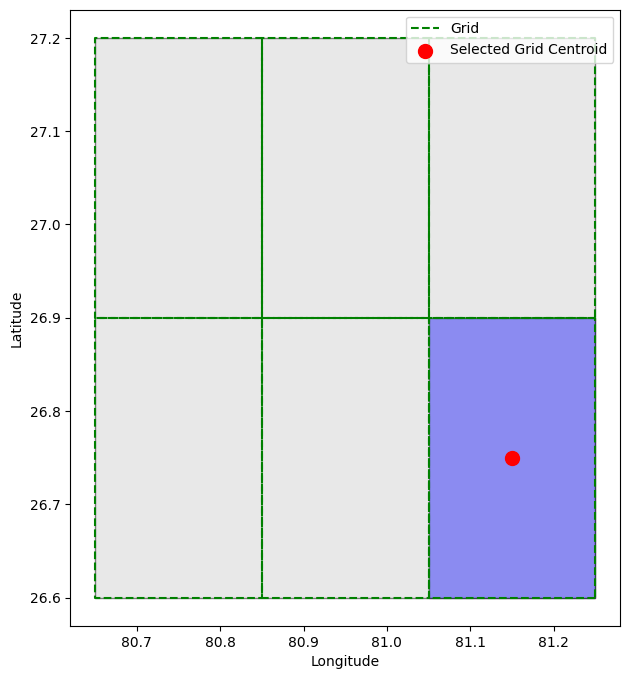

Selected grid saved as GeoJSON: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/lucknow_airshed_small.geojson


In [16]:



region = "lucknow_airshed"  # Change this to the desired region
# Load airshed data
# airshed_path = f"/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson
airshed_path = f"/home/patel_zeel/kiln_compass_24/regions/shapes/{region}.geojson"
gdf_airshed = gpd.read_file(airshed_path)

# Save original CRS (EPSG:4326)
original_crs = gdf_airshed.crs

# Reproject to Equal-Area CRS (EPSG:6933)
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Get bounding box in meters
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds

# Divide into 8 equal parts (4 columns × 2 rows)
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

# Create grid cells
grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Convert grid to GeoDataFrame and clip with the airshed
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Convert back to original CRS
grid_gdf = grid_gdf.to_crs(original_crs)
gdf_airshed = gdf_airshed.to_crs(original_crs)

# # Select the **third grid cell in the upper row** (index 2 in row 0)
selected_grid = grid_gdf.iloc[[4]]  # Keep as GeoDataFrame

# Get centroid of selected grid cell
selected_centroid = selected_grid.geometry.centroid.iloc[0]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot airshed
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="lightgray", alpha=0.5, label="Delhi Airshed")

# Plot grid in green
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=1.5, linestyle="--", label="Grid")

# Highlight the selected grid cell in blue
selected_grid.plot(ax=ax, facecolor="blue", edgecolor="black", alpha=0.4, label="Selected Grid")

# Mark the centroid
ax.scatter(selected_centroid.x, selected_centroid.y, color="red", marker="o", s=100, label="Selected Grid Centroid")

# Customize plot
# ax.set_title("Delhi Airshed with Selected Upper Third Grid Cell", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

# Define output GeoJSON path
output_geojson_path = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/{region}_small.geojson"

# Save the selected grid cell as a GeoJSON file
selected_grid.to_file(output_geojson_path, driver="GeoJSON")

print(f"Selected grid saved as GeoJSON: {output_geojson_path}")


/tmp/ipykernel_42658/193954641.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
/tmp/ipykernel_42658/193954641.py:51: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ax.scatter(gdf_ncr_clipped.centroid.x, gdf_ncr_clipped.centroid.y,
/tmp/ipykernel_42658/193954641.py:59: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


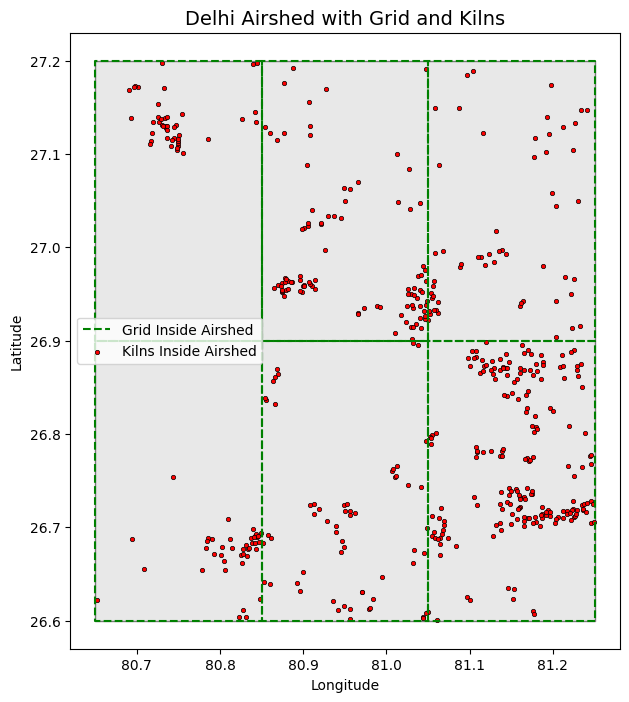

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

# Load GeoJSONs (EPSG:4326)
# airshed_path = "/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson"
ncr_data_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/after_hand_validation_data/india_v5/final/india_v5.geojson"

gdf_airshed = gpd.read_file(airshed_path)
gdf_ncr = gpd.read_file(ncr_data_path)

# Reproject to Equal-Area CRS (World Equidistant Cylindrical EPSG:6933)
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Get bounding box in meters
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds

# Divide into 8 equal parts (4 columns × 2 rows)
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

# Create grid cells
grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Convert to GeoDataFrame and clip grid to the airshed
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Convert back to EPSG:4326 for plotting
grid_gdf = grid_gdf.to_crs("EPSG:4326")
gdf_airshed = gdf_airshed.to_crs("EPSG:4326")

# Clip kilns data to the airshed
gdf_ncr_clipped = gpd.overlay(gdf_ncr, gdf_airshed, how="intersection")

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Delhi Airshed
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="lightgray", alpha=0.5, label="Delhi Airshed")

# Plot Clipped Grid in Green
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=1.5, linestyle="--", label="Grid Inside Airshed")
gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
ax.scatter(gdf_ncr_clipped.centroid.x, gdf_ncr_clipped.centroid.y, 
           color="red", s=10, edgecolor="black", linewidth=0.5, label="Kilns Inside Airshed")


# Customize plot
ax.set_title("Delhi Airshed with Grid and Kilns", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()

plt.show()
